# 10. Final corrected policy optimization

This is the frozen main specification used for the paper.

- 12-week promotion-planning horizon;
- no-promotion washout for terminal correction;
- the same behavioral draws for dynamic and myopic policies;
- product-specific empirically supported promotion actions;
- weekly predicted baseline-demand variation;
- fixed product-level regular prices and unit costs;
- category-level weekly promotion capacities.

Observed weekly costs are deliberately excluded from the main specification because they are strongly tied to the historical promotion calendar and are not defensible as action-independent counterfactual inputs. Notebook 11 uses the artifacts saved here for the policy-boundary, decomposition, and support analyses.

**Run this notebook from a fresh kernel from top to bottom.**

## 1. Imports, paths, and frozen configuration

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Sequence
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [CURRENT_DIR, CURRENT_DIR.parent]
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the "
        "repository root or the notebooks directory."
    )

for import_directory in [
    PROJECT_ROOT / "src",
    PROJECT_ROOT,
    CURRENT_DIR,
]:
    if (
        import_directory.is_dir()
        and str(import_directory) not in sys.path
    ):
        sys.path.insert(0, str(import_directory))

import corrected_promotion_analysis as cpa

from corrected_promotion_analysis import (
    PlanningSpec,
    SupportSpec,
    build_schedule_system,
    build_weekly_economic_profiles,
    coerce_action_sets,
    load_pickle,
    prepare_behavioral_draws,
    run_policy_grid,
    save_pickle,
    schedule_input_fingerprint,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

for directory in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Analysis module:", Path(cpa.__file__).resolve())

Project root: C:\Users\janza\price-of-extrapolation
Analysis module: C:\Users\janza\price-of-extrapolation\notebooks\corrected_promotion_analysis.py


In [2]:
# Frozen empirical design.
DECISION_HORIZON = 12
WASHOUT_HORIZONS = (0, 4, 6, 8, 10, 12)
MAXIMUM_WASHOUT = max(WASHOUT_HORIZONS)

COOLDOWN = 2
MAX_PROMOTIONS = 4
DISCOUNT_FACTOR = 0.995

MAIN_ALPHA = 2.24
ALPHA_GRID = np.unique(
    np.round(
        np.concatenate(
            [
                np.arange(1.40, 3.21, 0.05),
                np.array([MAIN_ALPHA]),
            ]
        ),
        4,
    )
)
CAPACITIES = (1, 2, 3, 8)

BASELINE_SUPPORT = SupportSpec(
    bin_width=0.05,
    minimum_depth=0.03,
    maximum_depth=0.60,
    minimum_observations=15,
    minimum_panels=3,
    maximum_positive_actions=3,
    matching_tolerance=0.03,
)

START_TEST_WEEK_OFFSET = 0
SCHEDULE_BATCH_SIZE = 256
COMPUTE_SECOND_BEST_ON_FULL_GRID = True
MILP_TIME_LIMIT_SECONDS = None

# Transparent washout-selection rules.
VDO_STABILITY_TOLERANCE = 0.05
TERMINAL_STATE_TOLERANCE = 0.01

ECONOMIC_PROFILE_MODE = (
    "weekly_predicted_demand_fixed_product_price_cost"
)

print("Economic profile:", ECONOMIC_PROFILE_MODE)
print("Alpha values:", len(ALPHA_GRID))
print("Capacities:", CAPACITIES)
print("Washout horizons:", WASHOUT_HORIZONS)

Economic profile: weekly_predicted_demand_fixed_product_price_cost
Alpha values: 38
Capacities: (1, 2, 3, 8)
Washout horizons: (0, 4, 6, 8, 10, 12)


## 2. Load calibrated behavior, supported actions, and held-out demand profiles

In [3]:
PRODUCT_DRAW_PATH = (
    PROCESSED_DIR
    / "product_stockpiling_behavioral_draws_v2.pkl"
)
PRODUCT_ACTION_SUPPORT_PATH = (
    TABLE_DIR
    / "product_supported_action_clusters.csv"
)
PRODUCT_ACTION_SET_PATH = (
    PROCESSED_DIR
    / "product_supported_action_sets.pkl"
)
SELECTED_SAMPLE_PATH = (
    PROCESSED_DIR
    / "paper_selected_sample.parquet"
)
DEMAND_PREDICTION_PATH = (
    PROCESSED_DIR
    / "final_demand_model_predictions.pkl"
)

required_paths = [
    PRODUCT_DRAW_PATH,
    PRODUCT_ACTION_SUPPORT_PATH,
    PRODUCT_ACTION_SET_PATH,
    SELECTED_SAMPLE_PATH,
    DEMAND_PREDICTION_PATH,
]

missing_paths = [
    path for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Required upstream artifacts are missing:\n"
        + "\n".join(
            f"  - {path}"
            for path in missing_paths
        )
    )


def prepare_support_table_compat(
    raw: pd.DataFrame,
) -> pd.DataFrame:
    # Standardize the support artifact used in this repository.
    frame = raw.copy()
    frame.columns = (
        frame.columns
        .astype(str)
        .str.strip()
        .str.lower()
    )

    aliases = {
        "bin_center": "depth_cluster",
        "depth": "depth_cluster",
        "promotion_depth": "depth_cluster",
        "action_depth": "depth_cluster",
        "representative_depth": "depth_cluster",
        "depth_center": "depth_cluster",
        "support_count": "observations",
        "n_observations": "observations",
        "observation_count": "observations",
        "support_observations": "observations",
        "count": "observations",
        "support_panels": "panels",
        "n_panels": "panels",
        "panel_count": "panels",
    }

    for source, target in aliases.items():
        if (
            target not in frame.columns
            and source in frame.columns
        ):
            frame[target] = frame[source]

    required = [
        "upc",
        "depth_cluster",
        "observations",
        "panels",
    ]
    missing = [
        column for column in required
        if column not in frame.columns
    ]

    if missing:
        raise ValueError(
            "Support table is missing standardized columns "
            f"{missing}. Available columns: "
            f"{frame.columns.tolist()}"
        )

    frame["upc"] = cpa.normalize_identifier(
        frame["upc"]
    )

    for column in [
        "depth_cluster",
        "observations",
        "panels",
    ]:
        frame[column] = pd.to_numeric(
            frame[column],
            errors="coerce",
        )

    if "action" in frame.columns:
        frame["action"] = pd.to_numeric(
            frame["action"],
            errors="coerce",
        )

    frame = frame.dropna(
        subset=required,
    ).copy()

    frame["depth_cluster"] = (
        frame["depth_cluster"]
        .astype(float)
        .round(6)
    )
    frame["observations"] = (
        frame["observations"]
        .astype(int)
    )
    frame["panels"] = (
        frame["panels"]
        .astype(int)
    )

    return (
        frame
        .sort_values(
            ["upc", "depth_cluster"],
            kind="stable",
        )
        .reset_index(drop=True)
    )


raw_draws = pd.read_pickle(
    PRODUCT_DRAW_PATH
)
draw_frame, draws_by_product = (
    prepare_behavioral_draws(raw_draws)
)

raw_support_table = pd.read_csv(
    PRODUCT_ACTION_SUPPORT_PATH
)
support_table = prepare_support_table_compat(
    raw_support_table
)

raw_action_artifact = pd.read_pickle(
    PRODUCT_ACTION_SET_PATH
)
products = sorted(draws_by_product)
action_sets = coerce_action_sets(
    raw_action_artifact,
    products,
)

selected_sample = pd.read_parquet(
    SELECTED_SAMPLE_PATH
)
demand_predictions = pd.read_pickle(
    DEMAND_PREDICTION_PATH
)

print("Products:", len(products))
print("Behavioral draws:", len(draw_frame))
print(
    "Supported positive actions:",
    sum(
        len(values) - 1
        for values in action_sets.values()
    ),
)

display(
    pd.DataFrame(
        {
            "upc": products,
            "actions": [
                ", ".join(
                    f"{100 * value:.0f}%"
                    for value in action_sets[upc]
                )
                for upc in products
            ],
            "draws": [
                len(
                    draws_by_product[upc]["weights"]
                )
                for upc in products
            ],
        }
    )
)

Products: 8
Behavioral draws: 3952
Supported positive actions: 23


,upc,actions,draws
0,1600066510,"0%, 6%, 25%, 50%",520
1,1600066590,"0%, 6%, 25%, 50%",524
2,1600066610,"0%, 5%, 25%, 50%",595
3,3800000110,"0%, 7%, 9%",323
4,3800000120,"0%, 4%, 30%, 55%",595
5,3800000127,"0%, 5%, 30%, 50%",467
6,3800001520,"0%, 4%, 19%, 49%",387
7,3800001611,"0%, 5%, 9%, 40%",541


In [4]:
# Build the held-out weekly profiles once, then retain only predicted
# demand variation. Price and cost factors are fixed to one.

(
    weekly_profile_table_raw,
    weekly_profiles_raw,
    source_weeks,
) = build_weekly_economic_profiles(
    selected_sample=selected_sample,
    demand_predictions=demand_predictions,
    products=products,
    decision_horizon=DECISION_HORIZON,
    maximum_washout=MAXIMUM_WASHOUT,
    start_test_week_offset=START_TEST_WEEK_OFFSET,
    model_name="product_promotion",
)


def demand_only_profiles(
    profiles: Mapping[
        str,
        Mapping[str, np.ndarray],
    ],
) -> dict[str, dict[str, np.ndarray]]:
    # Keep weekly demand variation and fix price and cost factors.
    output: dict[
        str,
        dict[str, np.ndarray],
    ] = {}

    for upc, values in profiles.items():
        demand_factor = np.asarray(
            values["demand_factor"],
            dtype=float,
        ).copy()

        output[str(upc)] = {
            "demand_factor": demand_factor,
            "price_factor": np.ones_like(
                demand_factor,
                dtype=float,
            ),
            "cost_factor": np.ones_like(
                demand_factor,
                dtype=float,
            ),
            "source_week": np.asarray(
                values["source_week"],
                dtype=int,
            ).copy(),
        }

    return output


weekly_profiles = demand_only_profiles(
    weekly_profiles_raw
)

weekly_profile_table = (
    weekly_profile_table_raw.copy()
)

weekly_profile_table[
    "source_price_factor"
] = weekly_profile_table["price_factor"]

weekly_profile_table[
    "source_cost_factor"
] = weekly_profile_table["cost_factor"]

weekly_profile_table["price_factor"] = 1.0
weekly_profile_table["cost_factor"] = 1.0
weekly_profile_table[
    "economic_profile_mode"
] = ECONOMIC_PROFILE_MODE

assert all(
    np.allclose(
        values["price_factor"],
        1.0,
    )
    for values in weekly_profiles.values()
)
assert all(
    np.allclose(
        values["cost_factor"],
        1.0,
    )
    for values in weekly_profiles.values()
)

profile_audit = (
    weekly_profile_table
    .groupby(
        "upc",
        observed=True,
    )
    .agg(
        demand_factor_min=(
            "demand_factor",
            "min",
        ),
        demand_factor_max=(
            "demand_factor",
            "max",
        ),
        demand_factor_std=(
            "demand_factor",
            "std",
        ),
        price_factor_min=(
            "price_factor",
            "min",
        ),
        price_factor_max=(
            "price_factor",
            "max",
        ),
        cost_factor_min=(
            "cost_factor",
            "min",
        ),
        cost_factor_max=(
            "cost_factor",
            "max",
        ),
    )
    .reset_index()
)

print("Source weeks:", source_weeks)
display(profile_audit.round(4))

Source weeks: [326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349]


,upc,demand_factor_min,demand_factor_max,demand_factor_std,price_factor_min,price_factor_max,cost_factor_min,cost_factor_max
0,1600066510,0.6914,1.0585,0.0999,1.0,1.0,1.0,1.0
1,1600066590,0.6826,1.2183,0.1571,1.0,1.0,1.0,1.0
2,1600066610,0.7108,1.1018,0.1293,1.0,1.0,1.0,1.0
3,3800000110,0.6864,1.0471,0.1142,1.0,1.0,1.0,1.0
4,3800000120,0.6881,1.1431,0.1242,1.0,1.0,1.0,1.0
5,3800000127,0.7556,1.4081,0.1483,1.0,1.0,1.0,1.0
6,3800001520,0.7847,1.1524,0.1155,1.0,1.0,1.0,1.0
7,3800001611,0.7793,1.0619,0.0910,1.0,1.0,1.0,1.0


## 3. Select a terminal washout

For speed, each candidate washout is evaluated only at the main funding value. The full funding grid is built only once, after the washout has been selected.

In [5]:
def load_or_build_schedule_system(
    *,
    cache_path: Path,
    planning: PlanningSpec,
    alpha_grid: Sequence[float],
) -> dict:
    # Load a current cache or rebuild it from the frozen inputs.
    expected_fingerprint = (
        schedule_input_fingerprint(
            draws_by_product=draws_by_product,
            weekly_profiles=weekly_profiles,
            action_sets=action_sets,
            planning=planning,
            alpha_grid=alpha_grid,
        )
    )

    if cache_path.is_file():
        cached = load_pickle(cache_path)

        if (
            cached.get("input_fingerprint")
            == expected_fingerprint
        ):
            print(
                "Loaded current cache:",
                cache_path.name,
            )
            return cached

    schedule_system = build_schedule_system(
        draws_by_product=draws_by_product,
        weekly_profiles=weekly_profiles,
        action_sets=action_sets,
        planning=planning,
        alpha_grid=alpha_grid,
        batch_size=SCHEDULE_BATCH_SIZE,
    )

    save_pickle(
        schedule_system,
        cache_path,
    )

    print(
        "Built schedule system:",
        cache_path.name,
    )

    return schedule_system

In [6]:
washout_runs = []
washout_systems = {}

for washout_horizon in WASHOUT_HORIZONS:
    planning = PlanningSpec(
        decision_horizon=DECISION_HORIZON,
        washout_horizon=washout_horizon,
        cooldown=COOLDOWN,
        max_promotions=MAX_PROMOTIONS,
        discount_factor=DISCOUNT_FACTOR,
        alpha_min=MAIN_ALPHA,
        alpha_max=MAIN_ALPHA,
    )

    cache_path = (
        PROCESSED_DIR
        / (
            "corrected_schedule_demand_only_"
            f"washout_check_w{washout_horizon}.pkl"
        )
    )

    schedule_system = (
        load_or_build_schedule_system(
            cache_path=cache_path,
            planning=planning,
            alpha_grid=[MAIN_ALPHA],
        )
    )

    washout_systems[
        washout_horizon
    ] = schedule_system

    run = run_policy_grid(
        schedule_system=schedule_system,
        draws_by_product=draws_by_product,
        weekly_profiles=weekly_profiles,
        action_sets=action_sets,
        support_table=support_table,
        alpha_values=[MAIN_ALPHA],
        capacities=CAPACITIES,
        compute_second_best=False,
        time_limit_seconds=(
            MILP_TIME_LIMIT_SECONDS
        ),
    )

    run["results"][
        "economic_profile_mode"
    ] = ECONOMIC_PROFILE_MODE

    washout_runs.append(run)


washout_results = (
    pd.concat(
        [
            run["results"]
            for run in washout_runs
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "capacity",
            "washout_horizon",
        ]
    )
    .reset_index(drop=True)
)

washout_results[
    "vdo_change_from_previous"
] = (
    washout_results
    .groupby(
        "capacity",
        observed=True,
    )["vdo"]
    .diff()
)

stability_rows = []

for washout_horizon in [
    value
    for value in WASHOUT_HORIZONS
    if value > 0
]:
    current = washout_results.loc[
        washout_results[
            "washout_horizon"
        ].eq(washout_horizon)
    ]

    maximum_vdo_change = float(
        current[
            "vdo_change_from_previous"
        ].abs().max()
    )

    maximum_terminal_state = float(
        current[
            [
                "maximum_terminal_state_dynamic",
                "maximum_terminal_state_myopic",
            ]
        ].max().max()
    )

    stability_rows.append(
        {
            "washout_horizon": (
                washout_horizon
            ),
            "maximum_absolute_vdo_change": (
                maximum_vdo_change
            ),
            "maximum_terminal_state": (
                maximum_terminal_state
            ),
            "vdo_stable": (
                maximum_vdo_change
                <= VDO_STABILITY_TOLERANCE
            ),
            "terminal_state_small": (
                maximum_terminal_state
                <= TERMINAL_STATE_TOLERANCE
            ),
        }
    )

washout_stability = pd.DataFrame(
    stability_rows
)

eligible_stable = washout_stability.loc[
    washout_stability["vdo_stable"]
    & washout_stability[
        "terminal_state_small"
    ]
]

if eligible_stable.empty:
    SELECTED_WASHOUT = MAXIMUM_WASHOUT
else:
    SELECTED_WASHOUT = int(
        eligible_stable[
            "washout_horizon"
        ].min()
    )

print(
    "Selected washout:",
    SELECTED_WASHOUT,
)

display(
    washout_results[
        [
            "capacity",
            "washout_horizon",
            "dynamic_profit",
            "myopic_profit",
            "vdo",
            "vdo_percent",
            "vdo_change_from_previous",
            "maximum_terminal_state_dynamic",
            "maximum_terminal_state_myopic",
        ]
    ]
)

display(washout_stability)

Built schedule system: corrected_schedule_demand_only_washout_check_w0.pkl
Built schedule system: corrected_schedule_demand_only_washout_check_w4.pkl
Built schedule system: corrected_schedule_demand_only_washout_check_w6.pkl
Built schedule system: corrected_schedule_demand_only_washout_check_w8.pkl
Built schedule system: corrected_schedule_demand_only_washout_check_w10.pkl
Built schedule system: corrected_schedule_demand_only_washout_check_w12.pkl
Selected washout: 12


,capacity,washout_horizon,dynamic_profit,myopic_profit,vdo,vdo_percent,vdo_change_from_previous,maximum_terminal_state_dynamic,maximum_terminal_state_myopic
0,1,0,2035.033344,2026.849456,8.183887,0.403774,NaN,0.592442,0.264336
1,1,4,2610.068804,2603.373605,6.695199,0.257174,-1.488688,0.074637,0.059028
2,1,6,2847.724918,2841.089631,6.635287,0.233547,-0.059913,0.048189,0.041608
3,1,8,3067.277271,3060.683179,6.594092,0.215445,-0.041195,0.036185,0.032762
4,1,10,3321.425451,3314.872179,6.553272,0.197693,-0.040819,0.029453,0.027320
5,1,12,3588.946865,3582.425643,6.521222,0.182034,-0.032051,0.024977,0.023451
6,2,0,2051.328479,2033.866353,17.462126,0.858568,NaN,0.583048,0.250953
7,2,4,2624.834732,2610.309494,14.525239,0.556457,-2.936887,0.065060,0.050574
8,2,6,2862.300359,2847.932982,14.367376,0.504484,-0.157862,0.041608,0.036562
9,2,8,3081.761307,3067.464010,14.297297,0.466095,-0.070079,0.032762,0.029770


,washout_horizon,maximum_absolute_vdo_change,maximum_terminal_state,vdo_stable,terminal_state_small
0,4,4.948425,0.074637,False,False
1,6,0.180202,0.048189,False,False
2,8,0.075981,0.036185,False,False
3,10,0.049682,0.029453,True,False
4,12,0.035092,0.024977,True,False


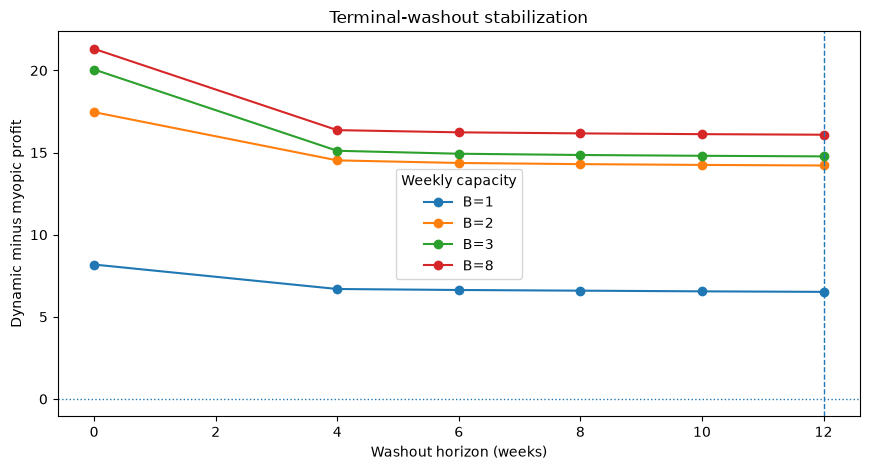

In [7]:
fig, ax = plt.subplots(
    figsize=(8.8, 4.8)
)

for capacity, group in (
    washout_results
    .groupby(
        "capacity",
        observed=True,
    )
):
    group = group.sort_values(
        "washout_horizon"
    )

    ax.plot(
        group["washout_horizon"],
        group["vdo"],
        marker="o",
        label=f"B={capacity}",
    )

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
ax.axvline(
    SELECTED_WASHOUT,
    linestyle="--",
    linewidth=1.0,
)
ax.set_xlabel(
    "Washout horizon (weeks)"
)
ax.set_ylabel(
    "Dynamic minus myopic profit"
)
ax.set_title(
    "Terminal-washout stabilization"
)
ax.legend(
    title="Weekly capacity"
)

fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = (
        FIGURE_DIR
        / (
            "corrected_vdo_washout_stability."
            f"{suffix}"
        )
    )
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

## 4. Run the final funding-capacity grid

In [8]:
primary_planning = PlanningSpec(
    decision_horizon=DECISION_HORIZON,
    washout_horizon=SELECTED_WASHOUT,
    cooldown=COOLDOWN,
    max_promotions=MAX_PROMOTIONS,
    discount_factor=DISCOUNT_FACTOR,
    alpha_min=float(ALPHA_GRID.min()),
    alpha_max=float(ALPHA_GRID.max()),
)

primary_cache_path = (
    PROCESSED_DIR
    / (
        "corrected_schedule_demand_only_"
        f"full_grid_w{SELECTED_WASHOUT}.pkl"
    )
)

primary_schedule_system = (
    load_or_build_schedule_system(
        cache_path=primary_cache_path,
        planning=primary_planning,
        alpha_grid=ALPHA_GRID,
    )
)

primary_run = run_policy_grid(
    schedule_system=(
        primary_schedule_system
    ),
    draws_by_product=draws_by_product,
    weekly_profiles=weekly_profiles,
    action_sets=action_sets,
    support_table=support_table,
    alpha_values=ALPHA_GRID,
    capacities=CAPACITIES,
    compute_second_best=(
        COMPUTE_SECOND_BEST_ON_FULL_GRID
    ),
    time_limit_seconds=(
        MILP_TIME_LIMIT_SECONDS
    ),
)

policy_results = (
    primary_run["results"]
    .copy()
    .sort_values(
        [
            "capacity",
            "alpha",
        ]
    )
    .reset_index(drop=True)
)

policy_results[
    "economic_profile_mode"
] = ECONOMIC_PROFILE_MODE

# Core numerical validity checks.
policy_results[
    "recomputed_vdo"
] = (
    policy_results["dynamic_profit"]
    - policy_results["myopic_profit"]
)

maximum_vdo_error = float(
    (
        policy_results["vdo"]
        - policy_results["recomputed_vdo"]
    ).abs().max()
)

if maximum_vdo_error > 1e-6:
    raise AssertionError(
        "Stored and recomputed VDO disagree. "
        f"Maximum error: {maximum_vdo_error}"
    )

negative_vdo = policy_results.loc[
    policy_results["vdo"] < -1e-6
]

if not negative_vdo.empty:
    raise AssertionError(
        "Dynamic profit falls below myopic profit "
        "at one or more grid points."
    )

dynamic_wide = (
    policy_results
    .pivot(
        index="alpha",
        columns="capacity",
        values="dynamic_profit",
    )
    .sort_index()
    .reindex(columns=list(CAPACITIES))
)

capacity_differences = (
    dynamic_wide.diff(axis=1)
)

if (
    capacity_differences[
        list(CAPACITIES)[1:]
    ]
    < -1e-6
).any().any():
    raise AssertionError(
        "Dynamic profit is not nondecreasing "
        "in weekly capacity."
    )

print(
    "Validation passed:",
    "VDO arithmetic, dynamic dominance, "
    "and capacity monotonicity."
)

main_rows = policy_results.loc[
    np.isclose(
        policy_results["alpha"],
        MAIN_ALPHA,
    )
]

display(
    main_rows[
        [
            "alpha",
            "capacity",
            "dynamic_profit",
            "myopic_profit",
            "vdo",
            "vdo_percent",
            "dynamic_promotion_count",
            "myopic_promotion_count",
            "dynamic_binding_weeks",
            "myopic_binding_weeks",
            "action_disagreements",
            "best_second_gap",
        ]
    ]
)

Built schedule system: corrected_schedule_demand_only_full_grid_w12.pkl
Validation passed: VDO arithmetic, dynamic dominance, and capacity monotonicity.


,alpha,capacity,dynamic_profit,myopic_profit,vdo,vdo_percent,dynamic_promotion_count,myopic_promotion_count,dynamic_binding_weeks,myopic_binding_weeks,action_disagreements,best_second_gap
17,2.24,1,3588.946865,3582.425643,6.521222,0.182034,12,12,12,12,18,0.227885
55,2.24,2,3603.279369,3589.065557,14.213812,0.396031,16,16,8,8,28,0.366122
93,2.24,3,3603.624975,3588.855906,14.769069,0.411526,16,16,3,4,20,0.040779
131,2.24,8,3603.875661,3587.787946,16.087716,0.448402,16,16,0,0,28,0.040779


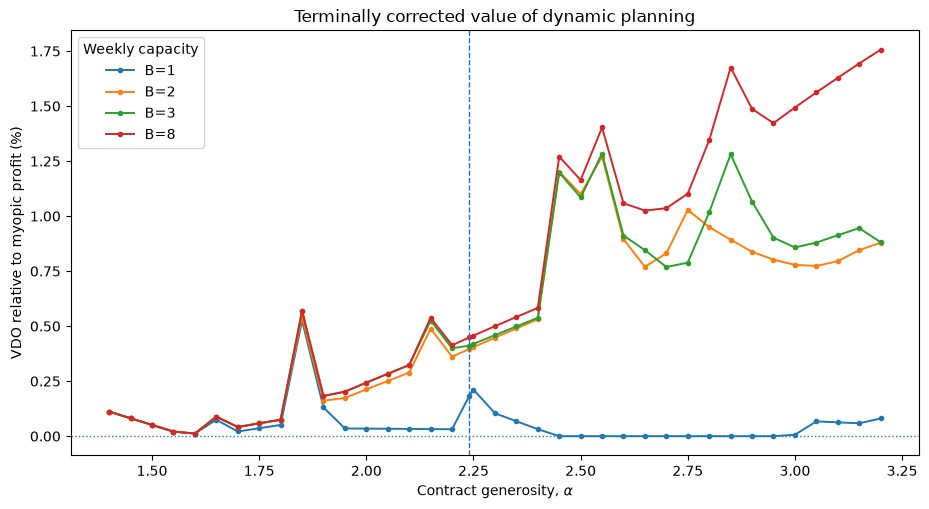

In [9]:
fig, ax = plt.subplots(
    figsize=(9.4, 5.2)
)

for capacity, group in (
    policy_results
    .groupby(
        "capacity",
        observed=True,
    )
):
    group = group.sort_values("alpha")

    ax.plot(
        group["alpha"],
        group["vdo_percent"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        label=f"B={capacity}",
    )

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
)
ax.axvline(
    MAIN_ALPHA,
    linestyle="--",
    linewidth=1.0,
)
ax.set_xlabel(
    r"Contract generosity, $\alpha$"
)
ax.set_ylabel(
    "VDO relative to myopic profit (%)"
)
ax.set_title(
    "Terminally corrected value of dynamic planning"
)
ax.legend(
    title="Weekly capacity"
)

fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = (
        FIGURE_DIR
        / (
            "corrected_vdo_percent_by_alpha_capacity."
            f"{suffix}"
        )
    )
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

## 5. Save the artifact used by Notebook 11

In [10]:
CORRECTED_ARTIFACT_PATH = (
    PROCESSED_DIR
    / "corrected_policy_optimization_artifact.pkl"
)

POLICY_RESULTS_PATH = (
    TABLE_DIR
    / "corrected_policy_results.csv"
)
WASHOUT_RESULTS_PATH = (
    TABLE_DIR
    / "corrected_policy_washout_results.csv"
)
WASHOUT_STABILITY_PATH = (
    TABLE_DIR
    / "corrected_policy_washout_stability.csv"
)
PRODUCT_DECOMPOSITION_PATH = (
    TABLE_DIR
    / "corrected_policy_product_decomposition.csv"
)
WEEKLY_DECOMPOSITION_PATH = (
    TABLE_DIR
    / "corrected_policy_weekly_decomposition.csv"
)
WEEKLY_PROFILE_PATH = (
    TABLE_DIR
    / "corrected_weekly_economic_profiles.csv"
)

artifact = {
    "selected_washout": (
        SELECTED_WASHOUT
    ),
    "main_alpha": (
        MAIN_ALPHA
    ),
    "alpha_grid": (
        ALPHA_GRID
    ),
    "capacities": (
        CAPACITIES
    ),
    "baseline_support": (
        BASELINE_SUPPORT
    ),
    "economic_profile_mode": (
        ECONOMIC_PROFILE_MODE
    ),
    "source_weeks": (
        source_weeks
    ),
    "products": (
        products
    ),
    "action_sets": (
        action_sets
    ),
    "support_table": (
        support_table
    ),
    "weekly_profile_table": (
        weekly_profile_table
    ),
    "weekly_profiles": (
        weekly_profiles
    ),
    "draw_frame": (
        draw_frame
    ),
    "draws_by_product": (
        draws_by_product
    ),
    "schedule_system": (
        primary_schedule_system
    ),
    "policy_results": (
        policy_results.drop(
            columns=["recomputed_vdo"]
        )
    ),
    "washout_results": (
        washout_results
    ),
    "washout_stability": (
        washout_stability
    ),
    "schedules": (
        primary_run["schedules"]
    ),
    "product_decomposition": (
        primary_run[
            "product_decomposition"
        ]
    ),
    "weekly_decomposition": (
        primary_run[
            "weekly_decomposition"
        ]
    ),
}

save_pickle(
    artifact,
    CORRECTED_ARTIFACT_PATH,
)

policy_results.drop(
    columns=["recomputed_vdo"]
).to_csv(
    POLICY_RESULTS_PATH,
    index=False,
)

washout_results.to_csv(
    WASHOUT_RESULTS_PATH,
    index=False,
)

washout_stability.to_csv(
    WASHOUT_STABILITY_PATH,
    index=False,
)

primary_run[
    "product_decomposition"
].to_csv(
    PRODUCT_DECOMPOSITION_PATH,
    index=False,
)

primary_run[
    "weekly_decomposition"
].to_csv(
    WEEKLY_DECOMPOSITION_PATH,
    index=False,
)

weekly_profile_table.to_csv(
    WEEKLY_PROFILE_PATH,
    index=False,
)

print("Saved:", CORRECTED_ARTIFACT_PATH)
print("Selected washout:", SELECTED_WASHOUT)
print("Policy rows:", len(policy_results))
print("Notebook 10 is complete. Run Notebook 11 next.")

Saved: C:\Users\janza\price-of-extrapolation\data\processed\corrected_policy_optimization_artifact.pkl
Selected washout: 12
Policy rows: 152
Notebook 10 is complete. Run Notebook 11 next.


## Interpretation guardrails

- Promotions may be selected only during weeks 1--12.
- No new promotions occur during the washout, but washout profit is included for both policies.
- Dynamic and myopic policies use the same behavioral draws and the same weekly predicted-demand profile.
- Regular prices and unit costs are fixed at their calibrated product-level values.
- Realized weekly inferred costs are excluded because they are strongly associated with the historical promotion calendar.
- Product and week decompositions are accounting decompositions of predicted profit, not causal decompositions.
- Notebook 11 should be used to identify the largest policy boundaries, explain schedule disagreements, and run the minimal support sensitivity.